# Machine Learning Assignment 2: Adult Income Classification

**Dataset:** Adult / Census Income dataset  
**Task:** Binary classification to predict whether income is `>50K` or `<=50K`  
**Models:** Logistic Regression, Decision Tree, KNN, Naive Bayes, Random Forest

Run this notebook in BITS Virtual Lab / Jupyter. Keep `adult.csv` in the same folder as this notebook.

## Step 1: Install required libraries

In [17]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib streamlit -q


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Import libraries

In [18]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix, classification_report
print("Libraries imported successfully")

Libraries imported successfully


## Step 3: Load adult.csv

Download `adult.csv` and keep it in the same folder as this notebook. Your shape `(32561, 15)` is valid for the assignment.

In [19]:
file_path = "adult.csv"
if not os.path.exists(r"C:\Users\DIS1RVQ\OneDrive-Deere&Co\OneDrive - Deere & Co\Goals\Mtech\BITS\Assignment\ML\ML_Assignment2\adult.csv"):
    raise FileNotFoundError("adult.csv not found. Upload adult.csv in the same folder and run again.")
df = pd.read_csv(r"C:\Users\DIS1RVQ\OneDrive-Deere&Co\OneDrive - Deere & Co\Goals\Mtech\BITS\Assignment\ML\ML_Assignment2\adult.csv")
print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 4: Clean column names and values

In [20]:
original_columns = df.columns.tolist()
df.columns = df.columns.str.strip().str.lower().str.replace(".", "-", regex=False).str.replace("_", "-", regex=False)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip().str.replace(".", "", regex=False)
for col in df.columns:
    df[col] = df[col].replace("?", np.nan)
df = df.dropna().reset_index(drop=True)
print("Original columns:", original_columns)
print("Cleaned columns:", df.columns.tolist())
print("Shape after cleaning:", df.shape)
df.head()

Original columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
Cleaned columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Shape after cleaning: (30162, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
1,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
2,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
3,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
4,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


## Step 5: Identify target column

In [21]:
target_col = "income" if "income" in df.columns else df.columns[-1]
print("Target column:", target_col)
print(df[target_col].value_counts())

Target column: income
income
<=50K    22654
>50K      7508
Name: count, dtype: int64


## Step 6: Split features and target

In [22]:
X = df.drop(columns=[target_col])
y_raw = df[target_col]
y = y_raw.astype(str).apply(lambda value: 1 if ">50K" in value else 0)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Feature shape: (30162, 14)
Target shape: (30162,)
income
0    22654
1     7508
Name: count, dtype: int64


## Step 7: Train-test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (24129, 14)
X_test: (6033, 14)


## Step 8: Create preprocessing pipeline

In [24]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_features), ("cat", encoder, categorical_features)])

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Step 9: Define all required models

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}
models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'KNN': KNeighborsClassifier(),
 'Naive Bayes': GaussianNB(),
 'Random Forest': RandomForestClassifier(random_state=42)}

## Step 10: Train models, calculate metrics, and save model files

In [26]:
os.makedirs("models", exist_ok=True)
results = []
trained_pipelines = {}
for model_name, model in models.items():
    print("Training:", model_name)
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps["classifier"], "predict_proba") else y_pred
    results.append({
        "ML Model Name": model_name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_score), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4)
    })
    safe_name = model_name.replace(" ", "_")
    joblib.dump(pipeline, f"models/{safe_name}.pkl", compress=3)
    trained_pipelines[model_name] = pipeline
results_df = pd.DataFrame(results)
results_df.to_csv("metrics_results.csv", index=False)
results_df

Training: Logistic Regression
Training: Decision Tree
Training: KNN
Training: Naive Bayes
Training: Random Forest


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8543,0.9136,0.7502,0.6218,0.6800,0.5911
1,Decision Tree,0.8152,0.7510,0.6303,0.6232,0.6267,0.5039
2,KNN,0.8341,0.8673,0.6832,0.6218,0.6511,0.5436
3,Naive Bayes,0.6010,0.8300,0.3795,0.9487,0.5421,0.3876
4,Random Forest,0.8563,0.9105,0.7490,0.6358,0.6878,0.5986


## Step 11: Confusion matrix for best model

Best model based on F1 score: Random Forest
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4531
        >50K       0.75      0.64      0.69      1502

    accuracy                           0.86      6033
   macro avg       0.82      0.78      0.80      6033
weighted avg       0.85      0.86      0.85      6033



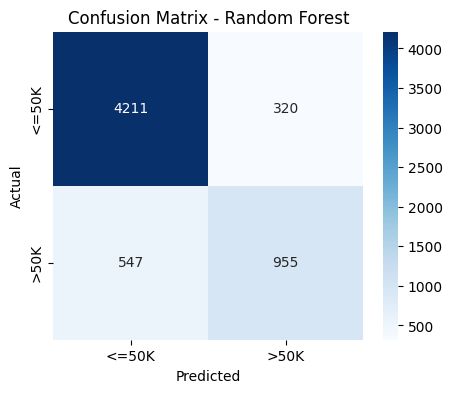

In [27]:
best_model_name = results_df.sort_values(by="F1", ascending=False).iloc[0]["ML Model Name"]
best_pipeline = trained_pipelines[best_model_name]
best_pred = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
print("Best model based on F1 score:", best_model_name)
print(classification_report(y_test, best_pred, target_names=["<=50K", ">50K"]))
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 12: Create test_data.csv

In [28]:
test_data = X_test.copy()
test_data[target_col] = y_test.map({0: "<=50K", 1: ">50K"}).values
test_data.to_csv("test_data.csv", index=False)
print("test_data.csv created successfully")
print("Shape:", test_data.shape)
test_data.head()

test_data.csv created successfully
Shape: (6033, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
3644,64,Private,116084,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,2635,0,40,United-States,<=50K
8212,60,Private,224097,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
28213,41,Federal-gov,219155,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,India,>50K
20793,23,Private,211160,12th,8,Married-civ-spouse,Handlers-cleaners,Own-child,White,Male,0,0,40,United-States,<=50K
7467,52,Private,131631,11th,7,Separated,Machine-op-inspct,Unmarried,Black,Male,0,0,40,United-States,<=50K


## Step 13: Create requirements.txt

In [29]:
requirements_text = """streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
"""
with open("requirements.txt", "w") as f:
    f.write(requirements_text)
print("requirements.txt created successfully")

requirements.txt created successfully


## Step 14: Create Streamlit app.py

In [30]:
app_code = 'import streamlit as st\nimport pandas as pd\nimport joblib\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix, classification_report\n\nst.set_page_config(page_title="Adult Income Classification", layout="wide")\nst.title("Adult Income Classification - ML Assignment 2")\nst.write("Upload test_data.csv, select a model, and view metrics, confusion matrix, and predictions.")\n\nmodel_options = {\n    "Logistic Regression": "models/Logistic_Regression.pkl",\n    "Decision Tree": "models/Decision_Tree.pkl",\n    "KNN": "models/KNN.pkl",\n    "Naive Bayes": "models/Naive_Bayes.pkl",\n    "Random Forest": "models/Random_Forest.pkl"\n}\n\nselected_model = st.selectbox("Select Machine Learning Model", list(model_options.keys()))\nuploaded_file = st.file_uploader("Upload test_data.csv", type=["csv"])\n\nif uploaded_file is not None:\n    data = pd.read_csv(uploaded_file)\n    st.subheader("Uploaded Test Data Preview")\n    st.dataframe(data.head())\n\n    target_col = "income" if "income" in data.columns else data.columns[-1]\n    X_test = data.drop(columns=[target_col])\n    y_test = data[target_col].astype(str).apply(lambda value: 1 if ">50K" in value else 0)\n\n    model = joblib.load(model_options[selected_model])\n    y_pred = model.predict(X_test)\n    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model.named_steps["classifier"], "predict_proba") else y_pred\n\n    metrics_df = pd.DataFrame({\n        "Metric": ["Accuracy", "AUC", "Precision", "Recall", "F1 Score", "MCC"],\n        "Value": [\n            accuracy_score(y_test, y_pred),\n            roc_auc_score(y_test, y_score),\n            precision_score(y_test, y_pred, zero_division=0),\n            recall_score(y_test, y_pred, zero_division=0),\n            f1_score(y_test, y_pred, zero_division=0),\n            matthews_corrcoef(y_test, y_pred)\n        ]\n    })\n\n    st.subheader("Evaluation Metrics")\n    st.dataframe(metrics_df)\n\n    st.subheader("Classification Report")\n    report = classification_report(y_test, y_pred, target_names=["<=50K", ">50K"], output_dict=True)\n    st.dataframe(pd.DataFrame(report).transpose())\n\n    st.subheader("Confusion Matrix")\n    cm = confusion_matrix(y_test, y_pred)\n    fig, ax = plt.subplots(figsize=(5, 4))\n    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"], ax=ax)\n    ax.set_xlabel("Predicted")\n    ax.set_ylabel("Actual")\n    ax.set_title(f"Confusion Matrix - {selected_model}")\n    st.pyplot(fig)\n\n    st.subheader("Prediction Output")\n    output_df = X_test.copy()\n    output_df["Actual"] = y_test.map({0: "<=50K", 1: ">50K"})\n    output_df["Predicted"] = pd.Series(y_pred).map({0: "<=50K", 1: ">50K"})\n    st.dataframe(output_df.head(50))\nelse:\n    st.info("Please upload test_data.csv generated from the notebook.")\n'
with open("app.py", "w") as f:
    f.write(app_code)
print("app.py created successfully")

app.py created successfully


## Step 15: Create README.md

In [31]:
readme_text = "# Machine Learning Assignment 2 - Adult Income Classification\n\n## a. Problem Statement\nThe objective of this project is to predict whether a person's income is greater than 50K per year or less than/equal to 50K per year using census-related demographic and employment attributes. This is a binary classification problem.\n\n## b. Dataset Description\nDataset Name: Adult Income / Census Income Dataset\n\nSource: UCI Machine Learning Repository or Kaggle Adult Census Income Dataset\n\nThe dataset contains details such as age, workclass, education, marital status, occupation, relationship, race, sex, capital gain, capital loss, hours per week, native country, and income.\n\nTarget variable: income\nClasses: <=50K and >50K\n\nThe downloaded dataset used in this assignment contains 32,561 instances and 15 columns, satisfying the assignment requirement of minimum 500 instances and minimum 12 features.\n\n## c. GitHub Repository Link\nhttps://github.com/your-username/ML-Assignment-2\n\n## d. Models Used\n1. Logistic Regression\n2. Decision Tree Classifier\n3. K-Nearest Neighbor Classifier\n4. Naive Bayes Classifier\n5. Random Forest Classifier\n\n## Evaluation Metrics\nAccuracy, AUC Score, Precision, Recall, F1 Score, Matthews Correlation Coefficient\n\n## Model Comparison Table\nPaste the table from metrics_results.csv here.\n\n## Model Performance Observations\n| ML Model Name | Observation about model performance |\n|---|---|\n| Logistic Regression | Good baseline model. Performs well when the feature-target relationship is mostly linear. |\n| Decision Tree | Easy to understand but may overfit. |\n| KNN | Gives reasonable performance but can be slower for larger datasets. |\n| Naive Bayes | Fast and simple. Performance depends on independence assumption between features. |\n| Random Forest | Usually strong because multiple trees reduce overfitting and improve generalization. |\n| Overall Winner | Select the model with the highest F1 and MCC score from the metrics table. |\n\n## Streamlit App Link\nhttps://your-app-name.streamlit.app\n\n## How to Run Locally\n```bash\npip install -r requirements.txt\nstreamlit run app.py\n```\n\n## Files Included\napp.py, requirements.txt, README.md, test_data.csv, metrics_results.csv, models folder, and notebook file.\n"
with open("README.md", "w") as f:
    f.write(readme_text)
print("README.md created successfully")

README.md created successfully


## Step 16: Final file check

In [32]:
print("Current folder files:")
for item in os.listdir("."):
    print(item)
print("\nModel folder files:")
for item in os.listdir("models"):
    print(item)

Current folder files:
.ipynb_checkpoints
app.py
metrics_results.csv
MLAssignment_2
ML_Assignment1.ipynb
ML_Assignment_2.ipynb
ML_Assignment_2_Adult_Income_Full.ipynb
ML_Assignment_2_Final
models
README.md
requirements.txt
test_data.csv

Model folder files:
Decision_Tree.pkl
KNN.pkl
Logistic_Regression.pkl
Naive_Bayes.pkl
Random_Forest.pkl


# Next process after notebook completion

1. Take screenshot in BITS Virtual Lab showing executed notebook and metrics table.
2. Upload `app.py`, `requirements.txt`, `README.md`, `test_data.csv`, `metrics_results.csv`, `models` folder, and notebook to GitHub.
3. Deploy on Streamlit Community Cloud using repo, branch `main`, file `app.py`.
4. Open Streamlit app and upload `test_data.csv`.
5. Verify metrics and confusion matrix are visible.
6. Prepare final PDF with GitHub link, Streamlit link, BITS screenshot, README content, comparison table, and observations table.